# 04 - Model Comparison

## Objective

The purpose of this notebook is to train and compare additional machine learning models for predicting California home sale prices.

In this notebook, we will:

- Load the cleaned training and testing datasets created during preprocessing.
- Train a Decision Tree Regression model.
- Train a Random Forest Regression model.
- Evaluate each model using the same metrics as the baseline model.
- Compare the performance of all models to determine which approach best predicts California home sale prices.

The results from this notebook will be used to identify whether tree-based models provide improved predictive performance over the baseline Linear Regression model.

In [39]:
# ============================================
# Import required libraries
# ============================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# Display all columns when inspecting DataFrames
pd.set_option("display.max_columns", None)

## Load the Cleaned Datasets

The preprocessing notebook produced separate training and testing datasets that are ready for machine learning.

In this section, we will:

- Load the cleaned training dataset.
- Load the cleaned testing dataset.
- Verify that both datasets were imported successfully.
- Confirm their dimensions before training and comparing the machine learning models.

In [40]:
# ============================================
# Load the cleaned training and testing datasets
# ============================================

data_path = Path("../data")

train = pd.read_csv(data_path / "train_cleaned.csv")
test = pd.read_csv(data_path / "test_cleaned.csv")

print("Datasets loaded successfully!\n")

print(f"Training rows: {train.shape[0]:,}")
print(f"Training columns: {train.shape[1]}")

print()

print(f"Testing rows: {test.shape[0]:,}")
print(f"Testing columns: {test.shape[1]}")

Datasets loaded successfully!

Training rows: 327,668
Training columns: 308

Testing rows: 12,024
Testing columns: 308


## Inspect the Datasets

Before training the models, it's a good idea to quickly inspect the datasets to make sure they loaded correctly.

We'll display the first few rows of both the training and testing datasets.

In [41]:
# Display the first few rows of the training dataset
train.head()

,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,LotSizeAcres,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,ViewYN_True,PoolPrivateYN_True,AttachedGarageYN_True,FireplaceYN_True,NewConstructionYN_True,"Levels_MultiSplit,One",Levels_One,"Levels_One,MultiSplit","Levels_One,ThreeOrMore","Levels_One,Two","Levels_One,Two,MultiSplit","Levels_One,Two,ThreeOrMore","Levels_One,Two,ThreeOrMore,MultiSplit",Levels_ThreeOrMore,"Levels_ThreeOrMore,MultiSplit","Levels_ThreeOrMore,One",Levels_Two,"Levels_Two,MultiSplit","Levels_Two,MultiSplit,One","Levels_Two,One","Levels_Two,ThreeOrMore","Levels_Two,ThreeOrMore,MultiSplit",CountyOrParish_Alpine,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Clark,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_Del Norte,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other County,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_SAN DIEGO,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Sierra,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,StateOrProvince_AZ,StateOrProvince_BC,StateOrProvince_CA,StateOrProvince_CO,StateOrProvince_FL,StateOrProvince_GA,StateOrProvince_ME,StateOrProvince_MO,StateOrProvince_NV,StateOrProvince_NY,StateOrProvince_OS,StateOrProvince_TN,StateOrProvince_TX,BuyerOfficeAOR_BayEast,BuyerOfficeAOR_BeverlyHillsGreaterLA,BuyerOfficeAOR_BeverlyHillsGreaterLa,BuyerOfficeAOR_Burbank,BuyerOfficeAOR_CLAW,BuyerOfficeAOR_CaliforniaDesert,BuyerOfficeAOR_CitrusValley,BuyerOfficeAOR_Claw,BuyerOfficeAOR_CoastalMendocino,BuyerOfficeAOR_Conejo,BuyerOfficeAOR_ContraCosta,BuyerOfficeAOR_Delta,BuyerOfficeAOR_Downey,BuyerOfficeAOR_EastValley,BuyerOfficeAOR_Fresno,BuyerOfficeAOR_Glendale,BuyerOfficeAOR_HemetSanJacinto,BuyerOfficeAOR_HighDesert,BuyerOfficeAOR_Inglewood,BuyerOfficeAOR_InlandValleys,BuyerOfficeAOR_JoshuaTreeGateway,BuyerOfficeAOR_Laguna,BuyerOfficeAOR_LakeCounty,BuyerOfficeAOR_MLSListings,BuyerOfficeAOR_MRMLS,BuyerOfficeAOR_Madera,BuyerOfficeAOR_Malibu,BuyerOfficeAOR_MariposaCounty,BuyerOfficeAOR_MercedCounty,BuyerOfficeAOR_Mlslistings,BuyerOfficeAOR_MontebelloDistrict,BuyerOfficeAOR_Mrmls,BuyerOfficeAOR_Newport,BuyerOfficeAOR_NorthSanDiegoCounty,BuyerOfficeAOR_NorthSanLuisObispo,BuyerOfficeAOR_Oakland,BuyerOfficeAOR_OrangeCounty,BuyerOfficeAOR_Oroville,BuyerOfficeAOR_OutOfAreaBoard,BuyerOfficeAOR_OutofAreaBoard,BuyerOfficeAOR_PacificSouthwest,BuyerOfficeAOR_PacificWest,BuyerOfficeAOR_PalmSprings,BuyerOfficeAOR_PalosVerdesPeninsula,BuyerOfficeAOR_Paradise,BuyerOfficeAOR_PasadenaFoothills,BuyerOfficeAOR_PismoCoast,BuyerOfficeAOR_RanchoSoutheast,BuyerOfficeAOR_ReciprocalBoard,BuyerOfficeAOR_RimOTheWorld,BuyerOfficeAOR_SacramentoAssociationOfRealtorsInc,BuyerOfficeAOR_SacramentoAssociationofRealtorsInc,BuyerOfficeAOR_SanDiego,BuyerOfficeAOR_SanFrancisco,BuyerOfficeAOR_SanLuis

In [42]:
# Display the first few rows of the testing dataset
test.head()

,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,LotSizeAcres,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,ViewYN_True,PoolPrivateYN_True,AttachedGarageYN_True,FireplaceYN_True,NewConstructionYN_True,"Levels_MultiSplit,One",Levels_One,"Levels_One,MultiSplit","Levels_One,ThreeOrMore","Levels_One,Two","Levels_One,Two,MultiSplit","Levels_One,Two,ThreeOrMore","Levels_One,Two,ThreeOrMore,MultiSplit",Levels_ThreeOrMore,"Levels_ThreeOrMore,MultiSplit","Levels_ThreeOrMore,One",Levels_Two,"Levels_Two,MultiSplit","Levels_Two,MultiSplit,One","Levels_Two,One","Levels_Two,ThreeOrMore","Levels_Two,ThreeOrMore,MultiSplit",CountyOrParish_Alpine,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Clark,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_Del Norte,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other County,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_SAN DIEGO,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Sierra,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,StateOrProvince_AZ,StateOrProvince_BC,StateOrProvince_CA,StateOrProvince_CO,StateOrProvince_FL,StateOrProvince_GA,StateOrProvince_ME,StateOrProvince_MO,StateOrProvince_NV,StateOrProvince_NY,StateOrProvince_OS,StateOrProvince_TN,StateOrProvince_TX,BuyerOfficeAOR_BayEast,BuyerOfficeAOR_BeverlyHillsGreaterLA,BuyerOfficeAOR_BeverlyHillsGreaterLa,BuyerOfficeAOR_Burbank,BuyerOfficeAOR_CLAW,BuyerOfficeAOR_CaliforniaDesert,BuyerOfficeAOR_CitrusValley,BuyerOfficeAOR_Claw,BuyerOfficeAOR_CoastalMendocino,BuyerOfficeAOR_Conejo,BuyerOfficeAOR_ContraCosta,BuyerOfficeAOR_Delta,BuyerOfficeAOR_Downey,BuyerOfficeAOR_EastValley,BuyerOfficeAOR_Fresno,BuyerOfficeAOR_Glendale,BuyerOfficeAOR_HemetSanJacinto,BuyerOfficeAOR_HighDesert,BuyerOfficeAOR_Inglewood,BuyerOfficeAOR_InlandValleys,BuyerOfficeAOR_JoshuaTreeGateway,BuyerOfficeAOR_Laguna,BuyerOfficeAOR_LakeCounty,BuyerOfficeAOR_MLSListings,BuyerOfficeAOR_MRMLS,BuyerOfficeAOR_Madera,BuyerOfficeAOR_Malibu,BuyerOfficeAOR_MariposaCounty,BuyerOfficeAOR_MercedCounty,BuyerOfficeAOR_Mlslistings,BuyerOfficeAOR_MontebelloDistrict,BuyerOfficeAOR_Mrmls,BuyerOfficeAOR_Newport,BuyerOfficeAOR_NorthSanDiegoCounty,BuyerOfficeAOR_NorthSanLuisObispo,BuyerOfficeAOR_Oakland,BuyerOfficeAOR_OrangeCounty,BuyerOfficeAOR_Oroville,BuyerOfficeAOR_OutOfAreaBoard,BuyerOfficeAOR_OutofAreaBoard,BuyerOfficeAOR_PacificSouthwest,BuyerOfficeAOR_PacificWest,BuyerOfficeAOR_PalmSprings,BuyerOfficeAOR_PalosVerdesPeninsula,BuyerOfficeAOR_Paradise,BuyerOfficeAOR_PasadenaFoothills,BuyerOfficeAOR_PismoCoast,BuyerOfficeAOR_RanchoSoutheast,BuyerOfficeAOR_ReciprocalBoard,BuyerOfficeAOR_RimOTheWorld,BuyerOfficeAOR_SacramentoAssociationOfRealtorsInc,BuyerOfficeAOR_SacramentoAssociationofRealtorsInc,BuyerOfficeAOR_SanDiego,BuyerOfficeAOR_SanFrancisco,BuyerOfficeAOR_SanLuis

## Separate the Features and Target

Machine learning models use one variable as the value they are trying to predict, while all remaining variables are used to help make that prediction.

For this project:

- **ClosePrice** is the target variable because it represents the home's final sale price.
- All remaining columns will be used as predictor variables.

In [43]:
# ============================================
# Separate the predictor variables and target
# ============================================

# X contains all of the information we'll use
# to predict a home's sale price.
X_train = train.drop(columns="ClosePrice")
X_test = test.drop(columns="ClosePrice")

# y contains the actual sale prices we're trying to predict.
y_train = train["ClosePrice"]
y_test = test["ClosePrice"]

## Verify the Training Data

Before training the models, we'll verify that the predictor variables (`X`) and target variable (`y`) were separated correctly.

In [44]:
print(f"Training features: {X_train.shape}")
print(f"Training target:   {y_train.shape}")

print()

print(f"Testing features:  {X_test.shape}")
print(f"Testing target:    {y_test.shape}")

Training features: (327668, 307)
Training target:   (327668,)

Testing features:  (12024, 307)
Testing target:    (12024,)


## Why Linear Regression?

Linear Regression serves as the baseline model for this project.

It predicts home sale prices by assuming a linear relationship between the property features and the sale price. While this approach is simple and easy to interpret, it may not capture the more complex relationships that exist in real estate data.

The results from this model provide a benchmark that the Decision Tree and Random Forest models will be compared against.

## Train the Linear Regression Model

We'll first train a Linear Regression model using the cleaned training dataset.

Training the baseline model within this notebook ensures that all three models are evaluated using the same training data, testing data, and evaluation process.

In [45]:
# ============================================
# Train the Linear Regression model
# ============================================

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

lr_predictions = linear_model.predict(X_test)

## Evaluate the Linear Regression Model

We'll calculate the same evaluation metrics that will later be used for the Decision Tree and Random Forest models.

Using identical evaluation metrics allows each model to be compared fairly.

In [46]:
# ============================================
# Calculate evaluation metrics
# ============================================

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = root_mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)
lr_mape = mean_absolute_percentage_error(y_test, lr_predictions)
lr_mdape = np.median(np.abs((y_test - lr_predictions) / y_test))

## Baseline Model Performance

The metrics below summarize the performance of the Linear Regression model on the testing dataset.

These results serve as the baseline against which the Decision Tree and Random Forest models will be evaluated.

In [47]:
# ============================================
# Display model performance
# ============================================

print("Linear Regression Performance\n")

print(f"Mean Absolute Error (MAE): ${lr_mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${lr_rmse:,.2f}")
print(f"R-squared (R²): {lr_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {lr_mape:.2%}")
print(f"Median Absolute Percentage Error (MdAPE): {lr_mdape:.2%}")

Linear Regression Performance

Mean Absolute Error (MAE): $599,678.86
Root Mean Square Error (RMSE): $1,454,754.39
R-squared (R²): 0.2484
Mean Absolute Percentage Error (MAPE): 65.03%
Median Absolute Percentage Error (MdAPE): 33.41%


## Why Decision Tree Regression?

Decision Tree Regression is a nonlinear machine learning model that predicts values by repeatedly splitting the data into smaller groups based on the features.

Unlike Linear Regression, Decision Trees can capture more complex relationships between property characteristics and home sale prices without assuming those relationships are linear.

However, individual Decision Trees are also more likely to overfit the training data, making it important to compare their performance with other models.

## Train the Decision Tree Model

Now that the training data has been prepared, we can fit a Decision Tree Regression model using the training dataset.

In [48]:
# ============================================
# Train the Decision Tree Regression model
# ============================================

# Create the Decision Tree model
decision_tree = DecisionTreeRegressor(
    random_state=42
)

# Train the model using the training data
decision_tree.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully!")

Decision Tree Regression model trained successfully!


## Generate Predictions

After training the Decision Tree Regression model, we can use it to predict home sale prices for the testing dataset.

These predictions will then be compared with the actual sale prices to evaluate the model's performance.

In [49]:
# ============================================
# Generate predictions using the Decision Tree model
# ============================================

dt_predictions = decision_tree.predict(X_test)

## Evaluate the Decision Tree Model

We'll evaluate the Decision Tree model using the same performance metrics as the baseline Linear Regression model:

- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)
- R-squared (R²)
- Mean Absolute Percentage Error (MAPE)
- Median Absolute Percentage Error (MdAPE)

Using the same evaluation metrics makes it possible to compare each model fairly.

In [50]:
# ============================================
# Calculate evaluation metrics
# ============================================

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = root_mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)
dt_mape = mean_absolute_percentage_error(y_test, dt_predictions)
dt_mdape = np.median(np.abs((y_test - dt_predictions) / y_test))

In [51]:
# ============================================
# Display model performance
# ============================================

print("Decision Tree Performance\n")

print(f"Mean Absolute Error (MAE): ${dt_mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${dt_rmse:,.2f}")
print(f"R-squared (R²): {dt_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {dt_mape:.2%}")
print(f"Median Absolute Percentage Error (MdAPE): {dt_mdape:.2%}")

Decision Tree Performance

Mean Absolute Error (MAE): $281,131.15
Root Mean Square Error (RMSE): $1,356,547.30
R-squared (R²): 0.3465
Mean Absolute Percentage Error (MAPE): 20.72%
Median Absolute Percentage Error (MdAPE): 10.69%


## Why Random Forest Regression?

Random Forest Regression builds many Decision Trees and combines their predictions to produce a final estimate.

By averaging the results from multiple trees, Random Forests typically reduce overfitting and provide more accurate and stable predictions than a single Decision Tree.

This makes Random Forest one of the most widely used machine learning algorithms for predicting home values.

## Train the Random Forest Model

Next, we'll train a Random Forest Regression model using the same training data.

Using the same training and testing datasets allows us to compare its performance directly with both the Linear Regression and Decision Tree models.

In [52]:
# ============================================
# Train the Random Forest Regression model
# ============================================

# Create the Random Forest model
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


## Generate Predictions

Now we'll use the trained Random Forest model to predict home sale prices for the testing dataset.

In [53]:
# ============================================
# Generate predictions using the Random Forest model
# ============================================

rf_predictions = random_forest.predict(X_test)

## Evaluate the Random Forest Model

We'll calculate the same evaluation metrics used for the previous models so that all three models can be compared fairly.

In [54]:
# ============================================
# Calculate evaluation metrics
# ============================================

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = root_mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)
rf_mdape = np.median(np.abs((y_test - rf_predictions) / y_test))

In [55]:
# ============================================
# Display model performance
# ============================================

print("Random Forest Performance\n")

print(f"Mean Absolute Error (MAE): ${rf_mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${rf_rmse:,.2f}")
print(f"R-squared (R²): {rf_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {rf_mape:.2%}")
print(f"Median Absolute Percentage Error (MdAPE): {rf_mdape:.2%}")

Random Forest Performance

Mean Absolute Error (MAE): $250,029.98
Root Mean Square Error (RMSE): $1,911,383.56
R-squared (R²): -0.2974
Mean Absolute Percentage Error (MAPE): 21.34%
Median Absolute Percentage Error (MdAPE): 7.96%


## Compare Model Performance

The table below summarizes the performance of all three machine learning models using the same evaluation metrics.

Comparing the models side by side makes it easier to identify which approach provides the best overall predictive performance.

In [56]:
# ============================================
# Compare model performance
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R²": [
        lr_r2,
        dt_r2,
        rf_r2
    ],
    "MAPE": [
        lr_mape,
        dt_mape,
        rf_mape
    ],
    "MdAPE": [
        lr_mdape,
        dt_mdape,
        rf_mdape
    ]
})

comparison

,Model,MAE,RMSE,R²,MAPE,MdAPE
0,Linear Regression,599678.860980,1.454754e+06,0.248439,0.650307,0.334114
1,Decision Tree,281131.152544,1.356547e+06,0.346486,0.207241,0.106907
2,Random Forest,250029.978302,1.911384e+06,-0.297420,0.213430,0.079555


In [57]:
# Format the comparison table

comparison_style = comparison.style.format({
    "MAE": "${:,.2f}",
    "RMSE": "${:,.2f}",
    "R²": "{:.4f}",
    "MAPE": "{:.2%}",
    "MdAPE": "{:.2%}"
})

comparison_style

,Model,MAE,RMSE,R²,MAPE,MdAPE
0,Linear Regression,"$599,678.86","$1,454,754.39",0.2484,65.03%,33.41%
1,Decision Tree,"$281,131.15","$1,356,547.30",0.3465,20.72%,10.69%
2,Random Forest,"$250,029.98","$1,911,383.56",-0.2974,21.34%,7.96%


## Visual Comparison of Model Predictions

Scatter plots provide a visual comparison between the actual home sale prices and each model's predicted sale prices.

Points closer to the diagonal line represent more accurate predictions.

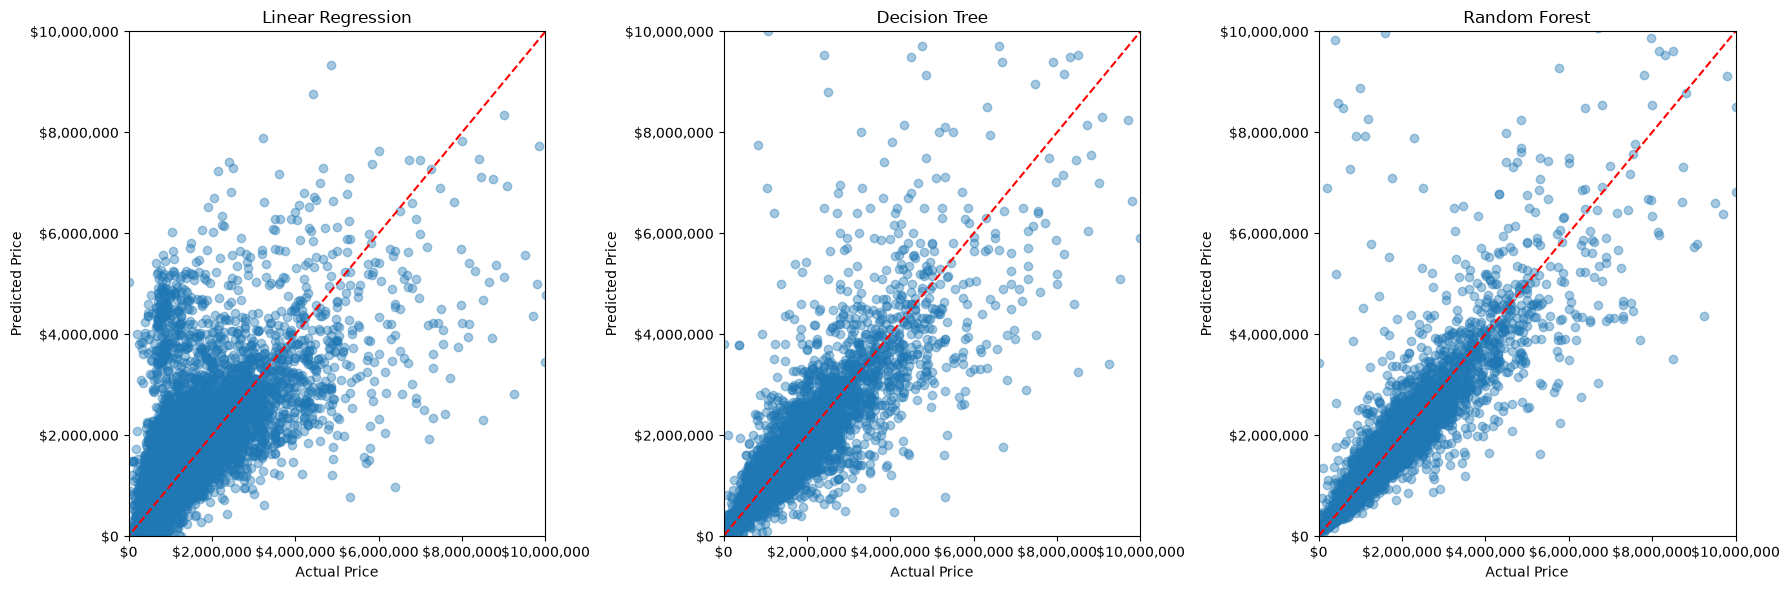

In [58]:
# ============================================
# Compare predictions from each model
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ("Linear Regression", lr_predictions),
    ("Decision Tree", dt_predictions),
    ("Random Forest", rf_predictions)
]

for ax, (name, predictions) in zip(axes, models):

    # Scatter plot of actual vs predicted prices
    ax.scatter(y_test, predictions, alpha=0.4)

    # Perfect prediction reference line
    min_price = min(y_test.min(), predictions.min())
    max_price = max(y_test.max(), predictions.max())

    ax.plot(
        [min_price, max_price],
        [min_price, max_price],
        color="red",
        linestyle="--"
    )

    ax.set_title(name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")

    # Format both axes as dollars
    ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

    limit = 10000000   # show up to $10 million

    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)

plt.tight_layout()
plt.show()

## Interpretation of the Prediction Plots

The scatter plots compare each model's predicted home sale prices with the actual sale prices in the testing dataset.

Points closer to the red dashed line represent more accurate predictions because the predicted value closely matches the actual sale price.

Comparing the three plots provides a visual assessment of how well each model predicts home sale prices across different price ranges.

## Feature Importance

Unlike Linear Regression, Random Forest models can estimate how important each feature was when making predictions.

The chart below displays the ten most important features identified by the Random Forest model. Features with larger importance values had a greater influence on the model's predictions.

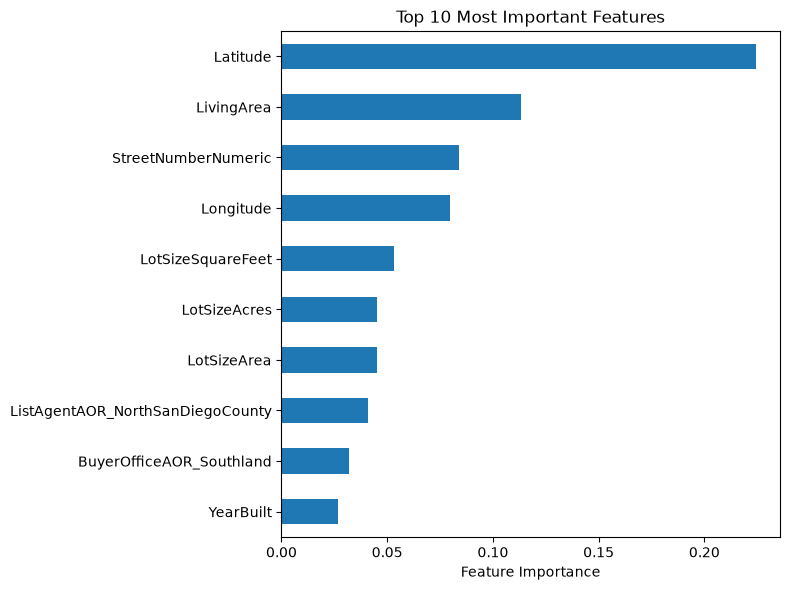

In [59]:
# ============================================
# Display the ten most important features
# ============================================

feature_importance = (
    pd.Series(
        random_forest.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()

## Model Comparison Results

The Decision Tree model substantially improved upon the baseline Linear Regression model across all evaluation metrics. It achieved lower prediction errors and explained a greater proportion of the variation in home sale prices.

The Random Forest model achieved the lowest Mean Absolute Error (MAE), indicating strong performance for most properties. However, several extremely large prediction errors caused the Root Mean Square Error (RMSE) to increase substantially and resulted in a negative R² value. These large errors are likely influenced by the presence of a small number of extremely high-priced properties within the training dataset. The Random Forest model also required noticeably longer training time than the Linear Regression and Decision Tree models because it builds and averages predictions from many individual decision trees.

Overall, the Decision Tree provided the most balanced performance across all evaluation metrics. Although the Random Forest achieved the lowest MAE, its predictions were strongly affected by a small number of extreme sale-price outliers.